<!-- # Feature Selection:

Now that we have analysed the data, we are ready to choose the features that will be used to train the model.

We first need to choose and preare the group of point-value metrics for the classical ML models.
Then we will need to compute the time-series features derived from the raw data like in 09.2_summarizing_group_of_gait_cycles.ipynb

Once selected, we will analyze the features in detail to choose the ones we will mvoe forward with to the next phase.... -->


In [2]:
import core.constants as c
from core.utils import save_df_as_table_image
import os

import warnings

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

In [3]:
data = pd.read_csv(c.RICKD_FEATURE_SELECTION_DATA_FILE_2)
display(data.head())

data.info(verbose=True)

,id,speed_output,step_width_left,step_width_right,stride_rate_left,stride_rate_right,stride_length_left,stride_length_right,swing_time_left,swing_time_right,...,pelvic_drop_peak_vel_left,pelvic_drop_peak_vel_right,vertical_oscillation_left,vertical_oscillation_right,age,height,weight,gender,dominantleg,is_injured
0,100001_20110531T161051,2.489233,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,0.4350,0.420,...,-82.090017,-57.417845,96.433793,92.586134,47.0,172.0,61.9,female,left,True
1,100002_20110601T140505,2.722687,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,0.4450,0.420,...,-57.724685,-60.462411,86.521432,94.945518,37.0,173.4,70.6,male,left,True
2,100003_20110601T095930,2.949904,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,0.4475,0.445,...,-82.171073,-95.302664,82.680986,76.611379,51.0,186.0,86.5,male,right,True
3,100004_20110203T120721,2.688014,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,0.4400,0.460,...,-63.319119,-49.646132,92.593339,83.273183,35.0,175.6,59.0,male,left,True
4,100004_20140929T102035,2.928598,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,0.4200,0.430,...,-32.717949,-52.004473,87.481400,75.091789,39.0,175.0,61.0,male,left,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 88 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1813 non-null   object 
 1   speed_output                    1813 non-null   float64
 2   step_width_left                 1813 non-null   float64
 3   step_width_right                1813 non-null   float64
 4   stride_rate_left                1813 non-null   float64
 5   stride_rate_right               1813 non-null   float64
 6   stride_length_left              1813 non-null   float64
 7   stride_length_right             1813 non-null   float64
 8   swing_time_left                 1813 non-null   float64
 9   swing_time_right                1813 non-null   float64
 10  stance_time_left                1813 non-null   float64
 11  stance_time_right               1813 non-null   float64
 12  pelvis_peak_drop_angle_left     18

In [4]:
def calculate_vif(df):
    # Fill missing values with column mean for VIF calculation
    df_filled = df.copy()
    for col in df_filled.columns:
        if df_filled[col].isnull().any():
            df_filled[col] = df_filled[col].fillna(df_filled[col].median())
    vif_data = pd.DataFrame()
    vif_data['feature'] = df_filled.columns
    vif_data['VIF'] = [variance_inflation_factor(df_filled.values, i) for i in range(df_filled.shape[1])]
    return vif_data

def predictor_analysis(df, target, categorical_cols, numerical_cols):
    results = []
    
    y = df[target]
    y_num = LabelEncoder().fit_transform(y)
    
    for col in df.columns:
        if col == target:
            continue
                
        # Detect variable type
        if col in numerical_cols:
            # Continuous variable
            group0 = df[df[target] == y.unique()[0]][col].dropna()
            group1 = df[df[target] == y.unique()[1]][col].dropna()
            
            # t-test (only if both groups have at least 2 values)
            if len(group0) > 1 and len(group1) > 1:
                t_pval = ttest_ind(group0, group1, nan_policy='omit').pvalue
            else:
                t_pval = np.nan
            
            # Pearson (drop rows with NaN in either col or y_num)
            valid_idx = df[col].notna()
            if valid_idx.sum() > 1:
                r_val, r_pval = pearsonr(df.loc[valid_idx, col], y_num[valid_idx])
            else:
                r_val, r_pval = np.nan, np.nan
            
            # Mutual Information (fillna with column mean)
            mi_input = df[[col]].copy()
            if mi_input[col].isnull().any():
                mi_input[col] = mi_input[col].fillna(mi_input[col].mean())
            mi_val = mutual_info_classif(mi_input, y_num, discrete_features=False)[0]
            
            results.append({
                'predictor': col,
                'type': 'continuous',
                'Mutual Info': mi_val,
                't-test p': t_pval,
                'Pearson r': r_val,
                'Pearson p': r_pval,
            })
        
        elif col in categorical_cols:
            # Categorical variable
            # Drop rows with NaN in col or y
            valid_idx = df[col].notna() & y.notna()
            contingency = pd.crosstab(df.loc[valid_idx, col], y[valid_idx])
            if contingency.shape[0] > 0 and contingency.shape[1] > 0:
                try:
                    chi2_pval = chi2_contingency(contingency)[1]
                except ValueError:
                    chi2_pval = np.nan
            else:
                chi2_pval = np.nan
            # For MI, fillna with a placeholder
            mi_input = df[[col]].copy()
            if mi_input[col].isnull().any():
                mi_input[col] = mi_input[col].fillna('missing')
            mi_val = mutual_info_classif(pd.get_dummies(mi_input), y_num, discrete_features=True)[0]
            
            results.append({
                'predictor': col,
                'type': 'categorical',
                'Mutual Info': mi_val,
                'Chi2 p': chi2_pval,
            })
        else:
            warnings.warn(f"Column {col} missing in categorical and numerical columns, skipping!")
    
    results_df = pd.DataFrame(results)
    
    # VIF for continuous predictors
    if numerical_cols:
        vif_df = calculate_vif(df[numerical_cols])
    else:
        vif_df = pd.DataFrame(columns=['feature', 'VIF'])
    
    return results_df.sort_values('Mutual Info', ascending=False), vif_df.sort_values('VIF', ascending=False)


In [5]:
categorical_cols = [
    "gender",
    "dominantleg",
    "is_injured"
]

numerical_cols = [
    "speed_output",
    "step_width_left",
    "step_width_right",
    "stride_rate_left",
    "stride_rate_right",
    "stride_length_left",
    "stride_length_right",
    "swing_time_left",
    "swing_time_right",
    "stance_time_left",
    "stance_time_right",
    "pelvis_peak_drop_angle_left",
    "pelvis_peak_drop_angle_right",
    "pelvis_drop_excursion_left",
    "pelvis_drop_excursion_right",
    "ankle_df_peak_angle_left",
    "ankle_df_peak_angle_right",
    "ankle_eve_peak_angle_left",
    "ankle_eve_peak_angle_right",
    "ankle_eve_percent_stance_left",
    "ankle_eve_percent_stance_right",
    "ankle_eve_excursion_left",
    "ankle_eve_excursion_right",
    "ankle_rot_peak_angle_left",
    "ankle_rot_peak_angle_right",
    "ankle_rot_excursion_left",
    "ankle_rot_excursion_right",
    "knee_flex_peak_angle_left",
    "knee_flex_peak_angle_right",
    "knee_add_peak_angle_left",
    "knee_add_peak_angle_right",
    "knee_add_excursion_left",
    "knee_add_excursion_right",
    "knee_abd_peak_angle_left",
    "knee_abd_peak_angle_right",
    "knee_abd_excursion_left",
    "knee_abd_excursion_right",
    "knee_rot_peak_angle_left",
    "knee_rot_peak_angle_right",
    "knee_rot_excursion_left",
    "knee_rot_excursion_right",
    "hip_ext_peak_angle_left",
    "hip_ext_peak_angle_right",
    "hip_add_peak_angle_left",
    "hip_add_peak_angle_right",
    "hip_add_excursion_left",
    "hip_add_excursion_right",
    "hip_rot_peak_angle_left",
    "hip_rot_peak_angle_right",
    "hip_rot_excursion_left",
    "hip_rot_excursion_right",
    "foot_prog_angle_left",
    "foot_prog_angle_right",
    "foot_ang_at_hs_left",
    "foot_ang_at_hs_right",
    "mhw_exc_from_to_left",
    "mhw_exc_from_to_right",
    "ankle_eve_peak_vel_left",
    "ankle_eve_peak_vel_right",
    "ankle_rot_peak_vel_left",
    "ankle_rot_peak_vel_right",
    "knee_abd_peak_vel_left",
    "knee_abd_peak_vel_right",
    "knee_add_peak_vel_left",
    "knee_add_peak_vel_right",
    "hip_abd_peak_vel_left",
    "hip_abd_peak_vel_right",
    "knee_rot_peak_vel_left",
    "knee_rot_peak_vel_right",
    "hip_rot_peak_vel_left",
    "hip_rot_peak_vel_right",
    "pronation_onset_left",
    "pronation_onset_right",
    "supination_timing_left",
    "supination_timing_right",
    "hip_add_peak_vel_left",
    "hip_add_peak_vel_right",
    "pelvic_drop_peak_vel_left",
    "pelvic_drop_peak_vel_right",
    "vertical_oscillation_left",
    "vertical_oscillation_right",
    "age",
    "height",
    "weight"
]

results_df, vif_df = predictor_analysis(data, target='is_injured', categorical_cols=categorical_cols, numerical_cols=numerical_cols)

with pd.option_context('display.max_rows', None):
    display(results_df)
    display(vif_df)

save_df_as_table_image(results_df, os.path.join(c.RICKD_RESULTS_FOLDER, 'predictor_analysis_results_step1.png'))
save_df_as_table_image(vif_df, os.path.join(c.RICKD_RESULTS_FOLDER, 'predictor_analysis_VIF_step_1.png'))

/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_93841/3152111270.py:81: UserWarning: Column id missing in categorical and numerical columns, skipping!
  warnings.warn(f"Column {col} missing in categorical and numerical columns, skipping!")
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,predictor,type,Mutual Info,t-test p,Pearson r,Pearson p,Chi2 p
0,speed_output,continuous,0.072166,4.598916e-16,-0.189148,4.598916e-16,NaN
83,weight,continuous,0.059557,1.250710e-02,0.058726,1.250710e-02,NaN
10,stance_time_right,continuous,0.044085,2.247518e-22,0.225713,2.247518e-22,NaN
82,height,continuous,0.041959,6.275485e-01,0.011428,6.275485e-01,NaN
27,knee_flex_peak_angle_left,continuous,0.026576,2.801781e-03,-0.070153,2.801781e-03,NaN
81,age,continuous,0.025948,3.564850e-05,0.096954,3.564850e-05,NaN
54,foot_ang_at_hs_right,continuous,0.021414,2.903943e-07,0.120117,2.903943e-07,NaN
9,stance_time_left,continuous,0.021320,4.766818e-22,0.223978,4.766818e-22,NaN
44,hip_add_peak_angle_right,continuous,0.020730,7.558778e-03,0.062715,7.558778e-03,NaN
2,step_width_right,continuous,0.020608,7.707098e-05,0.092710,7.707098e-05,NaN


,feature,VIF
1,step_width_left,inf
2,step_width_right,inf
6,stride_length_right,3.190662e+06
5,stride_length_left,3.180674e+06
4,stride_rate_right,3.174847e+06
3,stride_rate_left,3.173127e+06
8,swing_time_right,1.699742e+04
7,swing_time_left,1.695731e+04
0,speed_output,1.139096e+04
10,stance_time_right,8.229825e+03


In [6]:
N = 5
print(f"Top {N} variables by Mutual Information:")
print(results_df.sort_values("Mutual Info", ascending=False)[["predictor", "Mutual Info"]].head(N))

# Top N variables by absolute correlation with the target
if "is_injured" in data.columns:
    # Only use numerical columns for correlation
    print(f"\nTop {N} variables by absolute correlation with is_injured:")
    results_df["abs_pearson_r"] = results_df["Pearson r"].abs()
    print(results_df.sort_values("abs_pearson_r", ascending=False)[["predictor", "Pearson r", "Pearson p"]].head(N))

# Top N by smallest t-test p - p < 0.05 there is a significant diff
if "t-test p" in results_df.columns:
    print(f"\nTop {N} variables by t-test p-value:")
    print(results_df.sort_values("t-test p", ascending=True)[["predictor", "t-test p"]].head(N))

# Top N by smallest Chi2 p - p < 0.05 there is a significant diff
if "Chi2 p" in results_df.columns:
    print(f"\nTop {2} variables by Chi2 p-value:")
    print(results_df.sort_values("Chi2 p", ascending=True)[["predictor", "Chi2 p"]].head(2))


Top 5 variables by Mutual Information:
                    predictor  Mutual Info
0                speed_output     0.072166
83                     weight     0.059557
10          stance_time_right     0.044085
82                     height     0.041959
27  knee_flex_peak_angle_left     0.026576

Top 5 variables by absolute correlation with is_injured:
                  predictor  Pearson r     Pearson p
10        stance_time_right   0.225713  2.247518e-22
9          stance_time_left   0.223978  4.766818e-22
0              speed_output  -0.189148  4.598916e-16
57  ankle_eve_peak_vel_left   0.186344  1.253574e-15
6       stride_length_right  -0.166458  9.849636e-13

Top 5 variables by t-test p-value:
                  predictor      t-test p
10        stance_time_right  2.247518e-22
9          stance_time_left  4.766818e-22
0              speed_output  4.598916e-16
57  ankle_eve_peak_vel_left  1.253574e-15
6       stride_length_right  9.849636e-13

Top 2 variables by Chi2 p-value:
     

In [7]:
vif_below_10 = (vif_df['VIF'] < 10).sum()
vif_above_10 = (vif_df['VIF'] >= 10).sum()
print(f"Variables with VIF < 10: {vif_below_10}")
print(f"Variables with VIF >= 10: {vif_above_10}")


Variables with VIF < 10: 10
Variables with VIF >= 10: 74


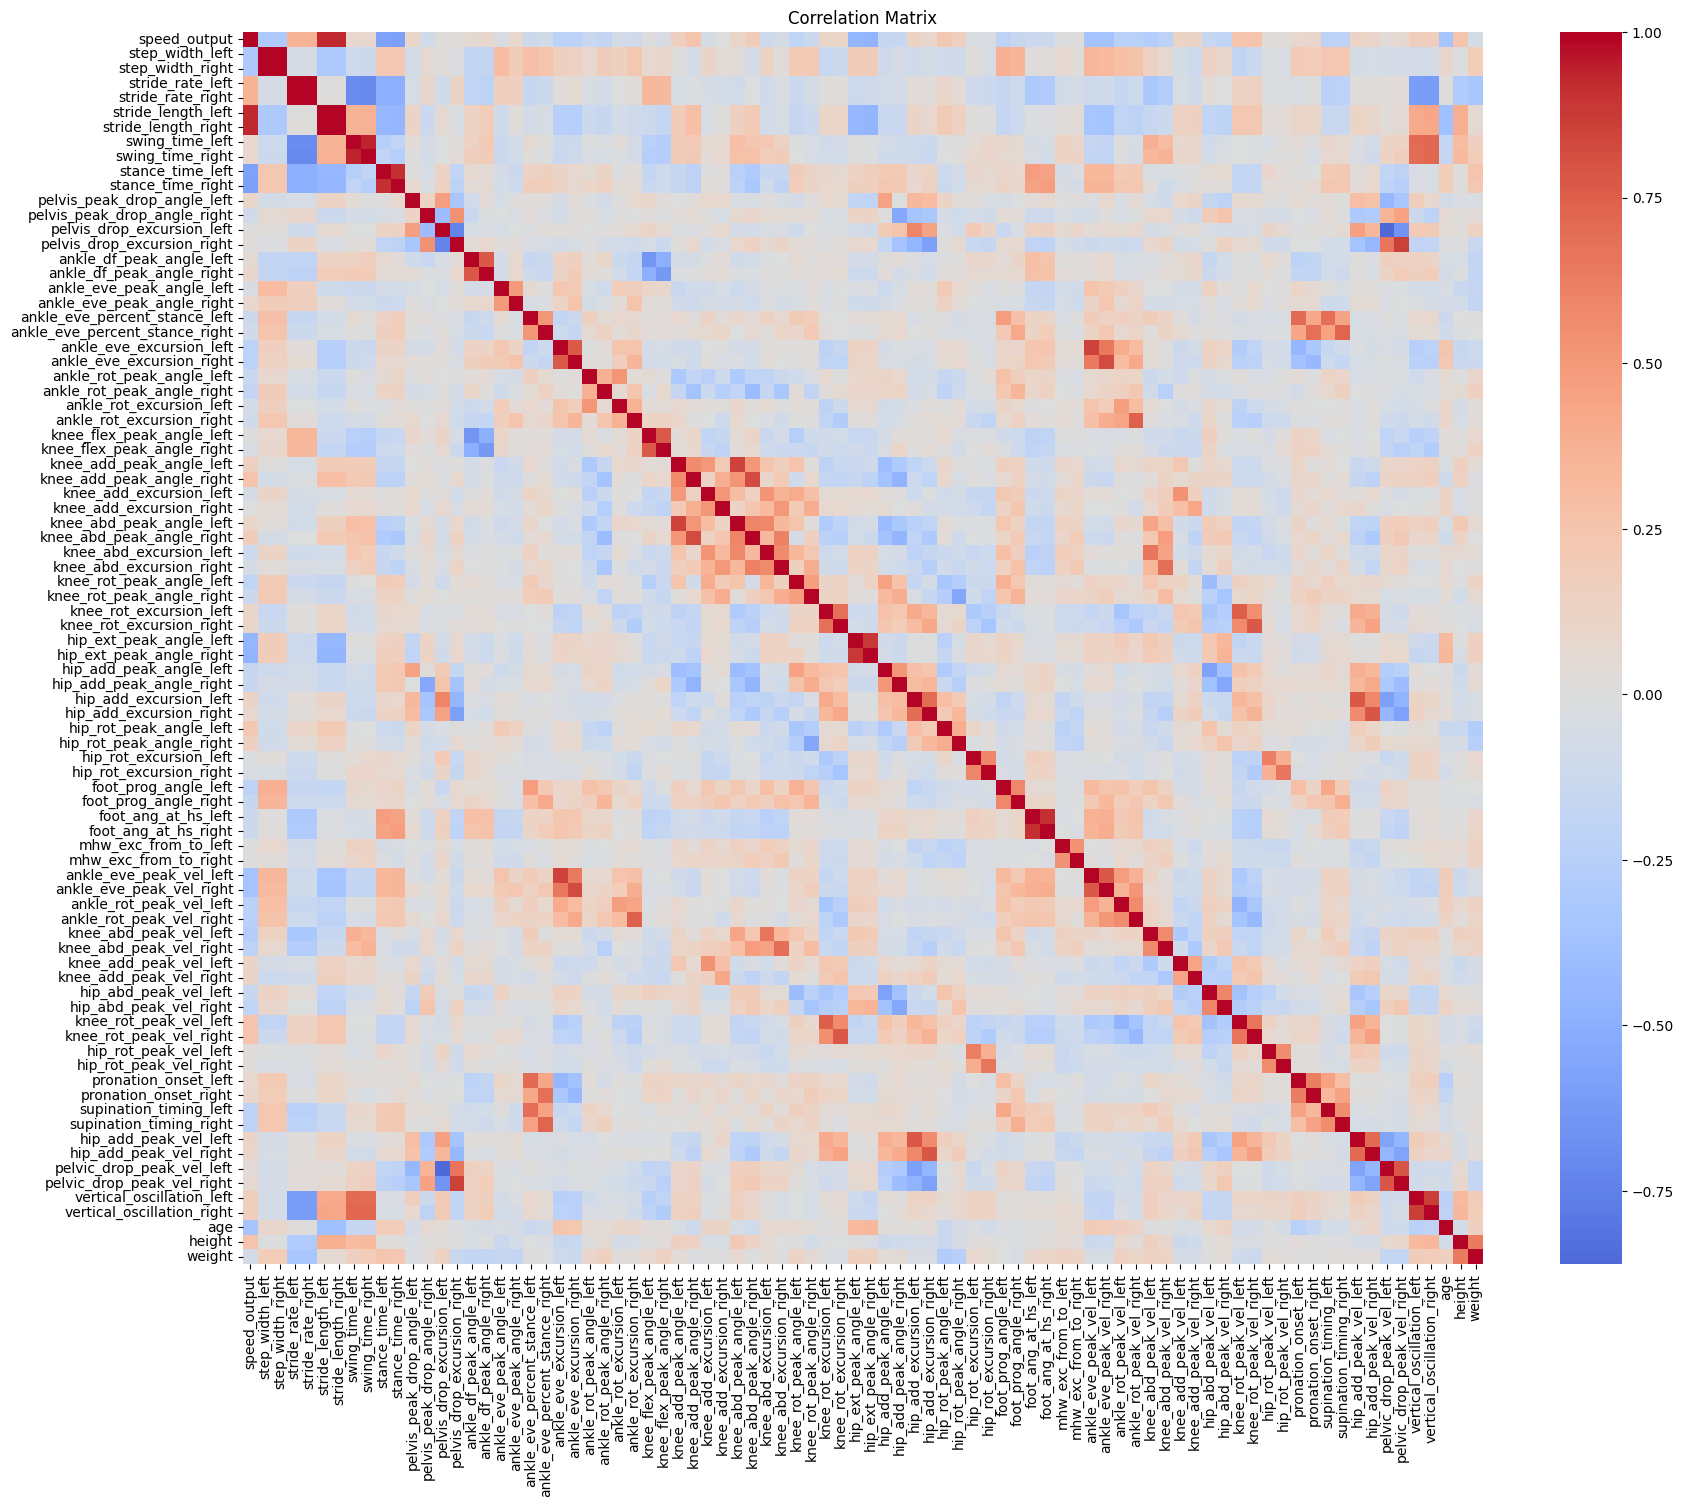

In [8]:
corr_matrix = data[numerical_cols].corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
import seaborn as sns
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


In [9]:
corr_matrix = data[numerical_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_reduced = data.drop(columns=to_drop)

print(f"Dropping {len(to_drop)} columns")
for col in to_drop:
    print(col)

df_reduced.info(verbose=True)

Dropping 7 columns
step_width_right
stride_rate_right
stride_length_left
stride_length_right
swing_time_right
stance_time_right
foot_ang_at_hs_right
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 81 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1813 non-null   object 
 1   speed_output                    1813 non-null   float64
 2   step_width_left                 1813 non-null   float64
 3   stride_rate_left                1813 non-null   float64
 4   swing_time_left                 1813 non-null   float64
 5   stance_time_left                1813 non-null   float64
 6   pelvis_peak_drop_angle_left     1813 non-null   float64
 7   pelvis_peak_drop_angle_right    1813 non-null   float64
 8   pelvis_drop_excursion_left      1813 non-null   float64
 9   pelvis_drop_excursion_right     1813 non-null   float64
 10  ankle_d

In [10]:
# Rerun with the dropped columns....
reduced_categorical_cols = [col for col in categorical_cols if col not in to_drop]

reduced_numerical_cols = [col for col in numerical_cols if col not in to_drop]

red_results_df, red_vif_df = predictor_analysis(df_reduced, target='is_injured', categorical_cols=reduced_categorical_cols, numerical_cols=reduced_numerical_cols)

with pd.option_context('display.max_rows', None):
    display(red_results_df)
    display(red_vif_df)

N = 20
print(f"Top {N} variables by Mutual Information:")
print(red_results_df.sort_values("Mutual Info", ascending=False)[["predictor", "Mutual Info"]].head(N))

# Top N variables by absolute correlation with the target
if "is_injured" in data.columns:
    # Only use numerical columns for correlation
    print(f"\nTop {N} variables by absolute correlation with is_injured:")
    red_results_df["abs_pearson_r"] = red_results_df["Pearson r"].abs()
    print(red_results_df.sort_values("abs_pearson_r", ascending=False)[["predictor", "Pearson r", "Pearson p"]].head(N))

# Top N by smallest t-test p - p < 0.05 there is a significant diff
if "t-test p" in red_results_df.columns:
    print(f"\nTop {N} variables by t-test p-value:")
    print(red_results_df.sort_values("t-test p", ascending=True)[["predictor", "t-test p"]].head(N))

# Top N by smallest Chi2 p - p < 0.05 there is a significant diff
if "Chi2 p" in red_results_df.columns:
    print(f"\nTop {2} variables by Chi2 p-value:")
    print(red_results_df.sort_values("Chi2 p", ascending=True)[["predictor", "Chi2 p"]].head(2))


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_93841/3152111270.py:81: UserWarning: Column id missing in categorical and numerical columns, skipping!
  warnings.warn(f"Column {col} missing in categorical and numerical columns, skipping!")


,predictor,type,Mutual Info,t-test p,Pearson r,Pearson p,Chi2 p
0,speed_output,continuous,0.072166,4.598916e-16,-0.189148,4.598916e-16,NaN
76,weight,continuous,0.071254,1.250710e-02,0.058726,1.250710e-02,NaN
74,age,continuous,0.054637,3.564850e-05,0.096954,3.564850e-05,NaN
4,stance_time_left,continuous,0.027896,4.766818e-22,0.223978,4.766818e-22,NaN
75,height,continuous,0.027564,6.275485e-01,0.011428,6.275485e-01,NaN
21,knee_flex_peak_angle_left,continuous,0.026576,2.801781e-03,-0.070153,2.801781e-03,NaN
67,supination_timing_right,continuous,0.021548,6.013287e-05,0.094087,6.013287e-05,NaN
38,hip_add_peak_angle_right,continuous,0.020730,7.558778e-03,0.062715,7.558778e-03,NaN
1,step_width_left,continuous,0.020608,7.707098e-05,0.092710,7.707098e-05,NaN
3,swing_time_left,continuous,0.020287,1.084218e-02,-0.059823,1.084218e-02,NaN


,feature,VIF
28,knee_abd_peak_angle_right,5305.971472
27,knee_abd_peak_angle_left,5089.717135
24,knee_add_peak_angle_right,1472.924916
23,knee_add_peak_angle_left,1452.884321
30,knee_abd_excursion_right,1056.265781
75,height,1006.867454
29,knee_abd_excursion_left,950.792498
3,swing_time_left,444.348503
25,knee_add_excursion_left,439.128725
2,stride_rate_left,438.934708


Top 20 variables by Mutual Information:
                        predictor  Mutual Info
0                    speed_output     0.072166
76                         weight     0.071254
74                            age     0.054637
4                stance_time_left     0.027896
75                         height     0.027564
21      knee_flex_peak_angle_left     0.026576
67        supination_timing_right     0.021548
38       hip_add_peak_angle_right     0.020730
1                 step_width_left     0.020608
3                 swing_time_left     0.020287
2                stride_rate_left     0.019719
45           foot_prog_angle_left     0.019169
27       knee_abd_peak_angle_left     0.018434
58          hip_abd_peak_vel_left     0.017335
10      ankle_df_peak_angle_right     0.017124
35        hip_ext_peak_angle_left     0.015964
50        ankle_eve_peak_vel_left     0.015819
24      knee_add_peak_angle_right     0.015610
13  ankle_eve_percent_stance_left     0.015187
33        knee_rot_e

In [11]:
# Top 20 variables by Mutual Information:
#                     predictor  Mutual Info
# 0                speed_output     0.072166
# 76                     weight     0.070734
# 74                        age     0.048487
# 75                     height     0.029757
# 21  knee_flex_peak_angle_left     0.026576
# 2            stride_rate_left     0.020861
# 38   hip_add_peak_angle_right     0.020730
# 1             step_width_left     0.020608
# 45       foot_prog_angle_left     0.019169
# 27   knee_abd_peak_angle_left     0.018434
# 58      hip_abd_peak_vel_left     0.017335
# 10  ankle_df_peak_angle_right     0.017124
# 35    hip_ext_peak_angle_left     0.015964
# 50    ankle_eve_peak_vel_left     0.015819
# 24  knee_add_peak_angle_right     0.015610
# 33    knee_rot_excursion_left     0.014694
# 44    hip_rot_excursion_right     0.014632
# 47        foot_ang_at_hs_left     0.013636
# 31   knee_rot_peak_angle_left     0.013454
# 49      mhw_exc_from_to_right     0.013438

# Top 20 variables by absolute correlation with is_injured:
#                       predictor  Pearson r     Pearson p
# 4              stance_time_left   0.223978  4.766818e-22
# 0                  speed_output  -0.189148  4.598916e-16
# 50      ankle_eve_peak_vel_left   0.186344  1.253574e-15
# 36     hip_ext_peak_angle_right   0.144139  7.033507e-10
# 51     ankle_eve_peak_vel_right   0.140359  1.949152e-09
# 52      ankle_rot_peak_vel_left   0.137502  4.135804e-09
# 9      ankle_df_peak_angle_left  -0.134652  8.631049e-09
# 71   pelvic_drop_peak_vel_right  -0.127973  4.558488e-08
# 35      hip_ext_peak_angle_left   0.124659  1.009405e-07
# 47          foot_ang_at_hs_left   0.119950  3.017154e-07
# 10    ankle_df_peak_angle_right  -0.117050  5.802903e-07
# 28    knee_abd_peak_angle_right  -0.109997  2.670879e-06
# 2              stride_rate_left  -0.108018  4.033071e-06
# 15     ankle_eve_excursion_left   0.107964  4.078722e-06
# 31     knee_rot_peak_angle_left   0.105511  6.729895e-06
# 41      hip_rot_peak_angle_left  -0.096982  3.529078e-05
# 74                          age   0.096954  3.564850e-05
# 8   pelvis_drop_excursion_right  -0.094971  5.117971e-05
# 67      supination_timing_right   0.094087  6.013287e-05
# 53     ankle_rot_peak_vel_right   0.093527  6.654650e-05

# Top 20 variables by t-test p-value:
#                       predictor      t-test p
# 4              stance_time_left  4.766818e-22
# 0                  speed_output  4.598916e-16
# 50      ankle_eve_peak_vel_left  1.253574e-15
# 36     hip_ext_peak_angle_right  7.033507e-10
# 51     ankle_eve_peak_vel_right  1.949152e-09
# 52      ankle_rot_peak_vel_left  4.135804e-09
# 9      ankle_df_peak_angle_left  8.631049e-09
# 71   pelvic_drop_peak_vel_right  4.558488e-08
# 35      hip_ext_peak_angle_left  1.009405e-07
# 47          foot_ang_at_hs_left  3.017154e-07
# 10    ankle_df_peak_angle_right  5.802903e-07
# 28    knee_abd_peak_angle_right  2.670879e-06
# 2              stride_rate_left  4.033071e-06
# 15     ankle_eve_excursion_left  4.078722e-06
# 31     knee_rot_peak_angle_left  6.729895e-06
# 41      hip_rot_peak_angle_left  3.529078e-05
# 74                          age  3.564850e-05
# 8   pelvis_drop_excursion_right  5.117971e-05
# 67      supination_timing_right  6.013287e-05
# 53     ankle_rot_peak_vel_right  6.654650e-05

# Top 2 variables by Chi2 p-value:
#       predictor    Chi2 p
# 77       gender  0.193481
# 78  dominantleg  0.630928

In [12]:
vif_below_10 = (vif_df['VIF'] < 10).sum()
vif_above_10 = (vif_df['VIF'] >= 10).sum()
print(f"Variables with VIF < 10: {vif_below_10}")
print(f"Variables with VIF >= 10: {vif_above_10}")

Variables with VIF < 10: 10
Variables with VIF >= 10: 74


<!-- ## Check for correlation between sides. -->

In [13]:
def print_high_correlations(data: pd.DataFrame, threshold: float = 0.6):
    """
    Print features with absolute correlation above the given threshold.

    Args:
        corr_matrix (pd.DataFrame): Correlation matrix.
        threshold (float): Absolute correlation threshold.
    """
    cm = data.corr()

    metric = cm.abs().fillna(0)
    np.fill_diagonal(metric.values, 0)

    top_corr_by_col = {}
    for col in metric.columns:
        s = metric[col][metric[col] > threshold].sort_values(ascending=False)
        if not s.empty:
            signed = cm.loc[s.index, col]
            top_corr_by_col[col] = signed.reindex(s.index).round(3)

    for col, s in top_corr_by_col.items():
        print(f"{col}:")
        for feat, val in s.items():
            print(f"  {feat}: {val:+.3f}")
        print()

print_high_correlations(corr_matrix, threshold=0.6)

speed_output:
  stride_length_right: +0.878
  stride_length_left: +0.877
  stance_time_right: +0.647
  stance_time_left: +0.646
  hip_ext_peak_angle_right: +0.624
  hip_ext_peak_angle_left: +0.611

step_width_left:
  step_width_right: +1.000

step_width_right:
  step_width_left: +1.000

stride_rate_left:
  stride_rate_right: +1.000
  swing_time_left: +0.782
  swing_time_right: +0.776
  vertical_oscillation_right: +0.685
  vertical_oscillation_left: +0.667

stride_rate_right:
  stride_rate_left: +1.000
  swing_time_left: +0.782
  swing_time_right: +0.776
  vertical_oscillation_right: +0.685
  vertical_oscillation_left: +0.667

stride_length_left:
  stride_length_right: +1.000
  speed_output: +0.877
  age: +0.616
  hip_ext_peak_angle_right: +0.607

stride_length_right:
  stride_length_left: +1.000
  speed_output: +0.878
  age: +0.616
  hip_ext_peak_angle_right: +0.607

swing_time_left:
  swing_time_right: +0.993
  vertical_oscillation_right: +0.876
  vertical_oscillation_left: +0.859
  s

<!-- To reduce collinearity we will do the following:
- Drop speed in favour of stride length
- Looking at the dominant leg, extract all metrics for the dominant leg, drop the other and extract the difference between the two as a new metric. -->


In [14]:
data_reduced_2 = data.drop(labels=["speed_output"], axis=1)
data_reduced_2

,id,step_width_left,step_width_right,stride_rate_left,stride_rate_right,stride_length_left,stride_length_right,swing_time_left,swing_time_right,stance_time_left,...,pelvic_drop_peak_vel_left,pelvic_drop_peak_vel_right,vertical_oscillation_left,vertical_oscillation_right,age,height,weight,gender,dominantleg,is_injured
0,100001_20110531T161051,0.123419,0.123419,78.947368,78.947368,1.891817,1.891817,0.4350,0.4200,0.320,...,-82.090017,-57.417845,96.433793,92.586134,47.0,172.0,61.9,female,left,True
1,100002_20110601T140505,0.032922,0.032922,81.632653,81.632653,2.001175,2.001175,0.4450,0.4200,0.290,...,-57.724685,-60.462411,86.521432,94.945518,37.0,173.4,70.6,male,left,True
2,100003_20110601T095930,0.097273,0.097273,78.947368,78.947368,2.241927,2.241927,0.4475,0.4450,0.315,...,-82.171073,-95.302664,82.680986,76.611379,51.0,186.0,86.5,male,right,True
3,100004_20110203T120721,0.011401,0.011401,82.191781,82.191781,1.962250,1.962250,0.4400,0.4600,0.290,...,-63.319119,-49.646132,92.593339,83.273183,35.0,175.6,59.0,male,left,True
4,100004_20140929T102035,0.029021,0.029021,83.333333,82.758621,2.108590,2.123233,0.4200,0.4300,0.300,...,-32.717949,-52.004473,87.481400,75.091789,39.0,175.0,61.0,male,left,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1808,201100_20150409T155915,0.108809,0.108809,76.433121,76.433121,2.190908,2.190908,0.4600,0.4650,0.330,...,-146.535658,-120.697186,74.753470,86.710600,52.0,170.0,80.0,male,right,True
1809,201101_20150413T143152,0.090986,0.090986,88.235294,88.235294,1.923449,1.923449,0.4075,0.4100,0.275,...,-56.000594,-79.974041,76.066245,67.343927,21.0,162.0,65.5,male,right,False
1810,201223_20140415T132359,0.157843,0.157843,80.000000,80.536913,2.157667,2.143282,0.4925,0.3875,0.255,...,-97.270798,-161.618698,109.127002,90.804104,29.0,171.0,72.0,male,left,False
1811,201224_20140417T141711,0.071881,0.071881,78.431373,78.947368,2.235128,2.220519,0.4600,0.4650,0.300,...,-160.743124,-153.188247,114.711973,119.143577,40.0,179.0,80.0,male,right,True


In [15]:
left_suffix = "_left"
right_suffix = "_right"


df_out = data_reduced_2.copy()

left_cols = [c for c in df_out.columns if c.endswith(left_suffix)]
right_cols = [c for c in df_out.columns if c.endswith(right_suffix)]

other_cols = [c for c in df_out.columns if not c.endswith(left_suffix) and not c.endswith(right_suffix)]
if len(other_cols) > 0:
    for col in other_cols:
        print(f"Column {col} is not a left or right column")

left_suffixes = {c[:-len(left_suffix)]: c for c in left_cols}
right_suffixes = {c[:-len(right_suffix)]: c for c in right_cols}
paired_suffixes = sorted(set(left_suffixes.keys()).intersection(right_suffixes.keys()))

# Build dominance mask from 'dominantleg' column
# Treat 'ambidextrous' and None as right-dominant
_dominantleg = df_out["dominantleg"].astype(str).str.lower()
left_dom_arr = _dominantleg.map({"left": True, "right": False, "ambidextrous": False}).fillna(False).values

# Compute dominant and difference per metric
def compute_dominant_and_diff(left_series: pd.Series, right_series: pd.Series) -> tuple[pd.Series, pd.Series]:
    left_vals = left_series.values
    right_vals = right_series.values

    dom_vals = np.where(left_dom_arr, left_vals, right_vals)
    other_vals = np.where(left_dom_arr, right_vals, left_vals)
    diff_vals = dom_vals - other_vals

    return pd.Series(dom_vals, index=left_series.index), pd.Series(diff_vals, index=left_series.index)

# Derive features for each paired metric
new_cols = {}
for suffix in paired_suffixes:
    l_col = left_suffixes[suffix]
    r_col = right_suffixes[suffix]
    dom_series, diff_series = compute_dominant_and_diff(df_out[l_col], df_out[r_col])
    new_cols[f"dom_leg_{suffix}"] = dom_series
    new_cols[f"dom_leg_diff_{suffix}"] = diff_series

for new_name, series in new_cols.items():
    df_out[new_name] = series

# dom_leg_diff_step_width is all 0...
cols_to_drop = left_cols + right_cols + ["dominantleg", "dom_leg_diff_step_width"]

data_reduced_3 = df_out.drop(columns=cols_to_drop, errors="ignore")


data_reduced_3.info()

Column id is not a left or right column
Column age is not a left or right column
Column height is not a left or right column
Column weight is not a left or right column
Column gender is not a left or right column
Column dominantleg is not a left or right column
Column is_injured is not a left or right column
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 85 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     1813 non-null   object 
 1   age                                    1812 non-null   float64
 2   height                                 1805 non-null   float64
 3   weight                                 1808 non-null   float64
 4   gender                                 1812 non-null   object 
 5   is_injured                             1813 non-null   bool   
 6   dom_leg_ankle_df_peak_angle       

/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_93841/2259846619.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  left_dom_arr = _dominantleg.map({"left": True, "right": False, "ambidextrous": False}).fillna(False).values


In [16]:
print_high_correlations(data_reduced_3.drop(columns=["is_injured", "id", "gender"]), threshold=0.7)

dom_leg_ankle_eve_excursion:
  dom_leg_ankle_eve_peak_vel: +0.827

dom_leg_diff_ankle_eve_excursion:
  dom_leg_diff_ankle_eve_peak_vel: +0.817

dom_leg_ankle_eve_peak_vel:
  dom_leg_ankle_eve_excursion: +0.827

dom_leg_diff_ankle_eve_peak_vel:
  dom_leg_diff_ankle_eve_excursion: +0.817

dom_leg_ankle_eve_percent_stance:
  dom_leg_supination_timing: +0.709

dom_leg_ankle_rot_excursion:
  dom_leg_ankle_rot_peak_vel: +0.738

dom_leg_ankle_rot_peak_vel:
  dom_leg_ankle_rot_excursion: +0.738

dom_leg_hip_add_excursion:
  dom_leg_hip_add_peak_vel: +0.797

dom_leg_diff_hip_add_excursion:
  dom_leg_diff_hip_add_peak_vel: +0.713

dom_leg_hip_add_peak_vel:
  dom_leg_hip_add_excursion: +0.797

dom_leg_diff_hip_add_peak_vel:
  dom_leg_diff_hip_add_excursion: +0.713

dom_leg_knee_abd_peak_angle:
  dom_leg_knee_add_peak_angle: +0.826

dom_leg_diff_knee_abd_peak_angle:
  dom_leg_diff_knee_add_peak_angle: +0.783

dom_leg_knee_add_peak_angle:
  dom_leg_knee_abd_peak_angle: +0.826

dom_leg_diff_knee_add

In [17]:
categorical_cols = [
    "id",
    "gender",
    "is_injured"
]
numerical_cols = [ c for c in data_reduced_3.columns if c not in categorical_cols]
dom_results_df, dom_vif_df = predictor_analysis(data_reduced_3, target='is_injured', categorical_cols=categorical_cols, numerical_cols=numerical_cols)

with pd.option_context('display.max_rows', None):
    # display(dom_results_df)
    display(dom_vif_df)

N = 20
print(f"Top {N} variables by Mutual Information:")
print(dom_results_df.sort_values("Mutual Info", ascending=False)[["predictor", "Mutual Info"]].head(N))

# Top N variables by absolute correlation with the target
if "is_injured" in data.columns:
    # Only use numerical columns for correlation
    print(f"\nTop {N} variables by absolute correlation with is_injured:")
    dom_results_df["abs_pearson_r"] = dom_results_df["Pearson r"].abs()
    print(dom_results_df.sort_values("abs_pearson_r", ascending=False)[["predictor", "Pearson r", "Pearson p"]].head(N))

# Top N by smallest t-test p - p < 0.05 there is a significant diff
if "t-test p" in dom_results_df.columns:
    print(f"\nTop {N} variables by t-test p-value:")
    print(dom_results_df.sort_values("t-test p", ascending=True)[["predictor", "t-test p"]].head(N))

# Top N by smallest Chi2 p - p < 0.05 there is a significant diff
if "Chi2 p" in dom_results_df.columns:
    print(f"\nTop {2} variables by Chi2 p-value:")
    print(dom_results_df.sort_values("Chi2 p", ascending=True)[["predictor", "Chi2 p"]].head(2))


,feature,VIF
41,dom_leg_knee_abd_peak_angle,11047.831334
47,dom_leg_knee_add_peak_angle,3052.769043
39,dom_leg_knee_abd_excursion,2210.428819
1,height,1001.820861
42,dom_leg_diff_knee_abd_peak_angle,831.607939
48,dom_leg_diff_knee_add_peak_angle,729.124378
45,dom_leg_knee_add_excursion,618.112259
78,dom_leg_swing_time,479.295165
74,dom_leg_stride_rate,372.524345
40,dom_leg_diff_knee_abd_excursion,341.867836


Top 20 variables by Mutual Information:
                                predictor  Mutual Info
3                                  weight     0.060455
1                                     age     0.035595
71                    dom_leg_stance_time     0.029922
21                 dom_leg_foot_ang_at_hs     0.021200
44       dom_leg_diff_knee_abd_peak_angle     0.021124
81                dom_leg_diff_swing_time     0.020903
73                     dom_leg_step_width     0.020608
80                     dom_leg_swing_time     0.019380
2                                  height     0.019349
26          dom_leg_diff_hip_abd_peak_vel     0.017510
5             dom_leg_ankle_df_peak_angle     0.017289
27              dom_leg_hip_add_excursion     0.016521
9            dom_leg_ankle_eve_peak_angle     0.014607
66     dom_leg_diff_pelvis_drop_excursion     0.014587
42        dom_leg_diff_knee_abd_excursion     0.014155
29             dom_leg_hip_add_peak_angle     0.014108
32          dom_leg_diff_

In [21]:
vif_below_10 = (dom_vif_df['VIF'] < 10).sum()
vif_above_10 = (dom_vif_df['VIF'] >= 10).sum()
print(f"Variables with VIF < 10: {vif_below_10}")
print(f"Variables with VIF >= 10: {vif_above_10}")

Variables with VIF < 10: 32
Variables with VIF >= 10: 50


In [22]:
save_df_as_table_image(dom_results_df, os.path.join(c.RICKD_RESULTS_FOLDER, 'predictor_analysis_results_step_2.png'))
save_df_as_table_image(dom_vif_df, os.path.join(c.RICKD_RESULTS_FOLDER, 'predictor_analysis_VIF_step_2.png'))

In [23]:
data_reduced_3.to_csv(c.RICKD_FEATURE_SELECTION_PART_2_DATA_FILE_2, index=False)